# Dynamic Customer Segmentation in Retail using Clustering

## Corrected behavioural, geographic, and firmographic model

Firmographic customer-market segmentation is operationalised through behavioural customer segments and geographic market segments. The research heading remains unchanged.

This notebook rebuilds the cumulative three-month customer snapshots, the Cycle 0 baseline, the warm-started fuzzy updates, the corrected customer transition states, the country market clusters, the combined firmographic labels, the SQLite evidence database, and the research figures.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display, Image

from csrs_model import rebuild_model

MODEL_DIRECTORY = Path.cwd()
if not (MODEL_DIRECTORY / 'Online UK_Retail.xlsx').exists():
    MODEL_DIRECTORY = (Path.cwd() / 'model' / 'pipeline b').resolve()
else:
    MODEL_DIRECTORY = MODEL_DIRECTORY.resolve()
MODEL_DIRECTORY

WindowsPath('C:/Users/siyam/OneDrive - University of the Western Cape/Desktop/Desktop stuff/Hon project/CSRS/model/pipeline b')

## Rebuild the corrected model

The rebuild fits the behavioural scaler and PCA model on Cycle 0 only, reuses them for later cycles, and precomputes Cycle 10.

In [2]:
validation_summary = rebuild_model(MODEL_DIRECTORY)
display(pd.Series(validation_summary, name='Corrected model validation'))

Corrected pipeline completed in 39.15 seconds


clean_transactions                                                           397884
customers                                                                      4338
cycles                                                                           11
cycle_10_customers                                                             4338
maximum_recency_days                                                            374
inactive_records                                                              10943
geographic_markets_cycle_10                                                      37
firmographic_segments_cycle_10                                                   12
mean_migration_rate                                                       52.848439
mean_xie_beni                                                              0.175447
database_path                     C:\Users\siyam\OneDrive - University of the We...
figure_directory                  C:\Users\siyam\OneDrive - University of th

## Dynamic model validation

Migration rate is calculated only for existing customers who can be compared with the previous cycle. Xie-Beni is reported as a fuzzy validity measure where lower values indicate more compact and separated clusters.

In [3]:
with sqlite3.connect(MODEL_DIRECTORY / 'csrs_pipeline_b.db') as connection:
    cycle_metrics = pd.read_sql_query(
        '''
        SELECT CycleID, CustomersProcessed, ActiveCustomers, InactiveCustomers,
               NewCustomers, ReactivatedCustomers, StableCustomers, MigratedCustomers,
               MigrationRate, SilhouetteScore, AverageMembership, XieBeniIndex, Converged
        FROM Dynamic_Cycle_Summary
        ORDER BY CAST(REPLACE(CycleID, 'Cycle_', '') AS INTEGER)
        ''',
        connection,
    )
display(cycle_metrics)

,CycleID,CustomersProcessed,ActiveCustomers,InactiveCustomers,NewCustomers,ReactivatedCustomers,StableCustomers,MigratedCustomers,MigrationRate,SilhouetteScore,AverageMembership,XieBeniIndex,Converged
0,Cycle_1,2134,1776,358,452,0,386,938,70.845921,0.504176,0.734356,0.168499,1
1,Cycle_2,2434,1874,560,300,61,746,767,50.693985,0.523596,0.772816,0.152534,1
2,Cycle_3,2718,1993,725,284,89,842,778,48.024691,0.544776,0.788161,0.206844,1
3,Cycle_4,2960,1991,969,242,106,768,875,53.256239,0.575098,0.805112,0.173618,1
4,Cycle_5,3148,2030,1118,188,125,853,864,50.320326,0.592081,0.814650,0.154420,1
5,Cycle_6,3317,1948,1369,169,109,811,859,51.437126,0.608961,0.827133,0.156303,1
6,Cycle_7,3616,2161,1455,299,232,756,874,53.619632,0.584869,0.818173,0.156433,1
7,Cycle_8,3974,2480,1494,358,224,794,1104,58.166491,0.562830,0.805033,0.191916,1
8,Cycle_9,4297,2851,1446,323,282,996,1250,55.654497,0.526346,0.793315,0.194459,1
9,Cycle_10,4338,2889,1449,41,81,1758,1009,36.465486,0.519822,0.795934,0.199447,1


## Corrected customer states

In [4]:
with sqlite3.connect(MODEL_DIRECTORY / 'csrs_pipeline_b.db') as connection:
    transition_states = pd.read_sql_query(
        '''
        SELECT CycleID, Transition_Status, COUNT(*) AS Customers
        FROM Customer_Transitions
        GROUP BY CycleID, Transition_Status
        ORDER BY CAST(REPLACE(CycleID, 'Cycle_', '') AS INTEGER), Transition_Status
        ''',
        connection,
    )
display(transition_states.pivot(index='CycleID', columns='Transition_Status', values='Customers').fillna(0))

Transition_Status,Existing Migrated,Existing Stable,Inactive,New,Reactivated
CycleID,,,,,
Cycle_1,938.0,386.0,358.0,452.0,0.0
Cycle_10,1009.0,1758.0,1449.0,41.0,81.0
Cycle_2,767.0,746.0,560.0,300.0,61.0
Cycle_3,778.0,842.0,725.0,284.0,89.0
Cycle_4,875.0,768.0,969.0,242.0,106.0
Cycle_5,864.0,853.0,1118.0,188.0,125.0
Cycle_6,859.0,811.0,1369.0,169.0,109.0
Cycle_7,874.0,756.0,1455.0,299.0,232.0
Cycle_8,1104.0,794.0,1494.0,358.0,224.0


## Geographic market segmentation

Country markets are segmented using customer count, revenue, orders per customer, revenue per customer, product diversity, repeat-purchase rate, and behavioural segment composition.

In [5]:
with sqlite3.connect(MODEL_DIRECTORY / 'csrs_pipeline_b.db') as connection:
    geographic_results = pd.read_sql_query(
        '''
        SELECT Country, Geographic_Segment_Name, Customer_Count, Revenue,
               Revenue_Per_Customer, Product_Diversity, Repeat_Purchase_Rate
        FROM Geographic_Segmentation
        WHERE CycleID = 'Cycle_10'
        ORDER BY Revenue DESC
        ''',
        connection,
    )
display(geographic_results)

,Country,Geographic_Segment_Name,Customer_Count,Revenue,Revenue_Per_Customer,Product_Diversity,Repeat_Purchase_Rate
0,United Kingdom,Dominant Core Market,3920,2908360.342,1113.034957,3061.0,0.482204
1,Netherlands,High-Value Export Market,9,103114.700,17185.783333,479.0,0.333333
2,France,Dominant Core Market,87,86271.870,1414.292951,1068.0,0.590164
3,Germany,Dominant Core Market,94,80626.620,1168.501739,1065.0,0.565217
4,EIRE,High-Value Export Market,3,80368.670,40184.335000,1275.0,1.000000
5,Australia,Dominant Core Market,9,26410.560,4401.760000,191.0,0.666667
6,Switzerland,Dominant Core Market,20,23859.010,1988.250833,532.0,0.416667
7,Spain,Dominant Core Market,29,21269.010,1012.810000,581.0,0.238095
8,Norway,Dominant Core Market,10,18562.250,2320.281250,308.0,0.625000
9,Belgium,Dominant Core Market,24,15896.910,935.112353,417.0,0.352941


## Firmographic customer-market segmentation

Each firmographic label combines one behavioural customer segment with one geographic market segment. For example, Champions in a High-Value Export Market become High-Value Export Champions.

In [6]:
with sqlite3.connect(MODEL_DIRECTORY / 'csrs_pipeline_b.db') as connection:
    firmographic_results = pd.read_sql_query(
        '''
        SELECT Firmographic_Segment_Name, COUNT(*) AS Customers
        FROM Firmographic_Customer_Segmentation
        WHERE CycleID = 'Cycle_10'
        GROUP BY Firmographic_Segment_Name
        ORDER BY Customers DESC
        ''',
        connection,
    )
display(firmographic_results)

,Firmographic_Segment_Name,Customers
0,Dominant Core Hibernating / Lost,1415
1,Dominant Core Mid-Tier Occasionals,1361
2,Dominant Core Champions,908
3,Dominant Core Core Loyalists,591
4,Growth Export Hibernating / Lost,33
5,Growth Export Mid-Tier Occasionals,15
6,High-Value Export Hibernating / Lost,4
7,High-Value Export Core Loyalists,3
8,High-Value Export Champions,3
9,High-Value Export Mid-Tier Occasionals,2


## Corrected research figures

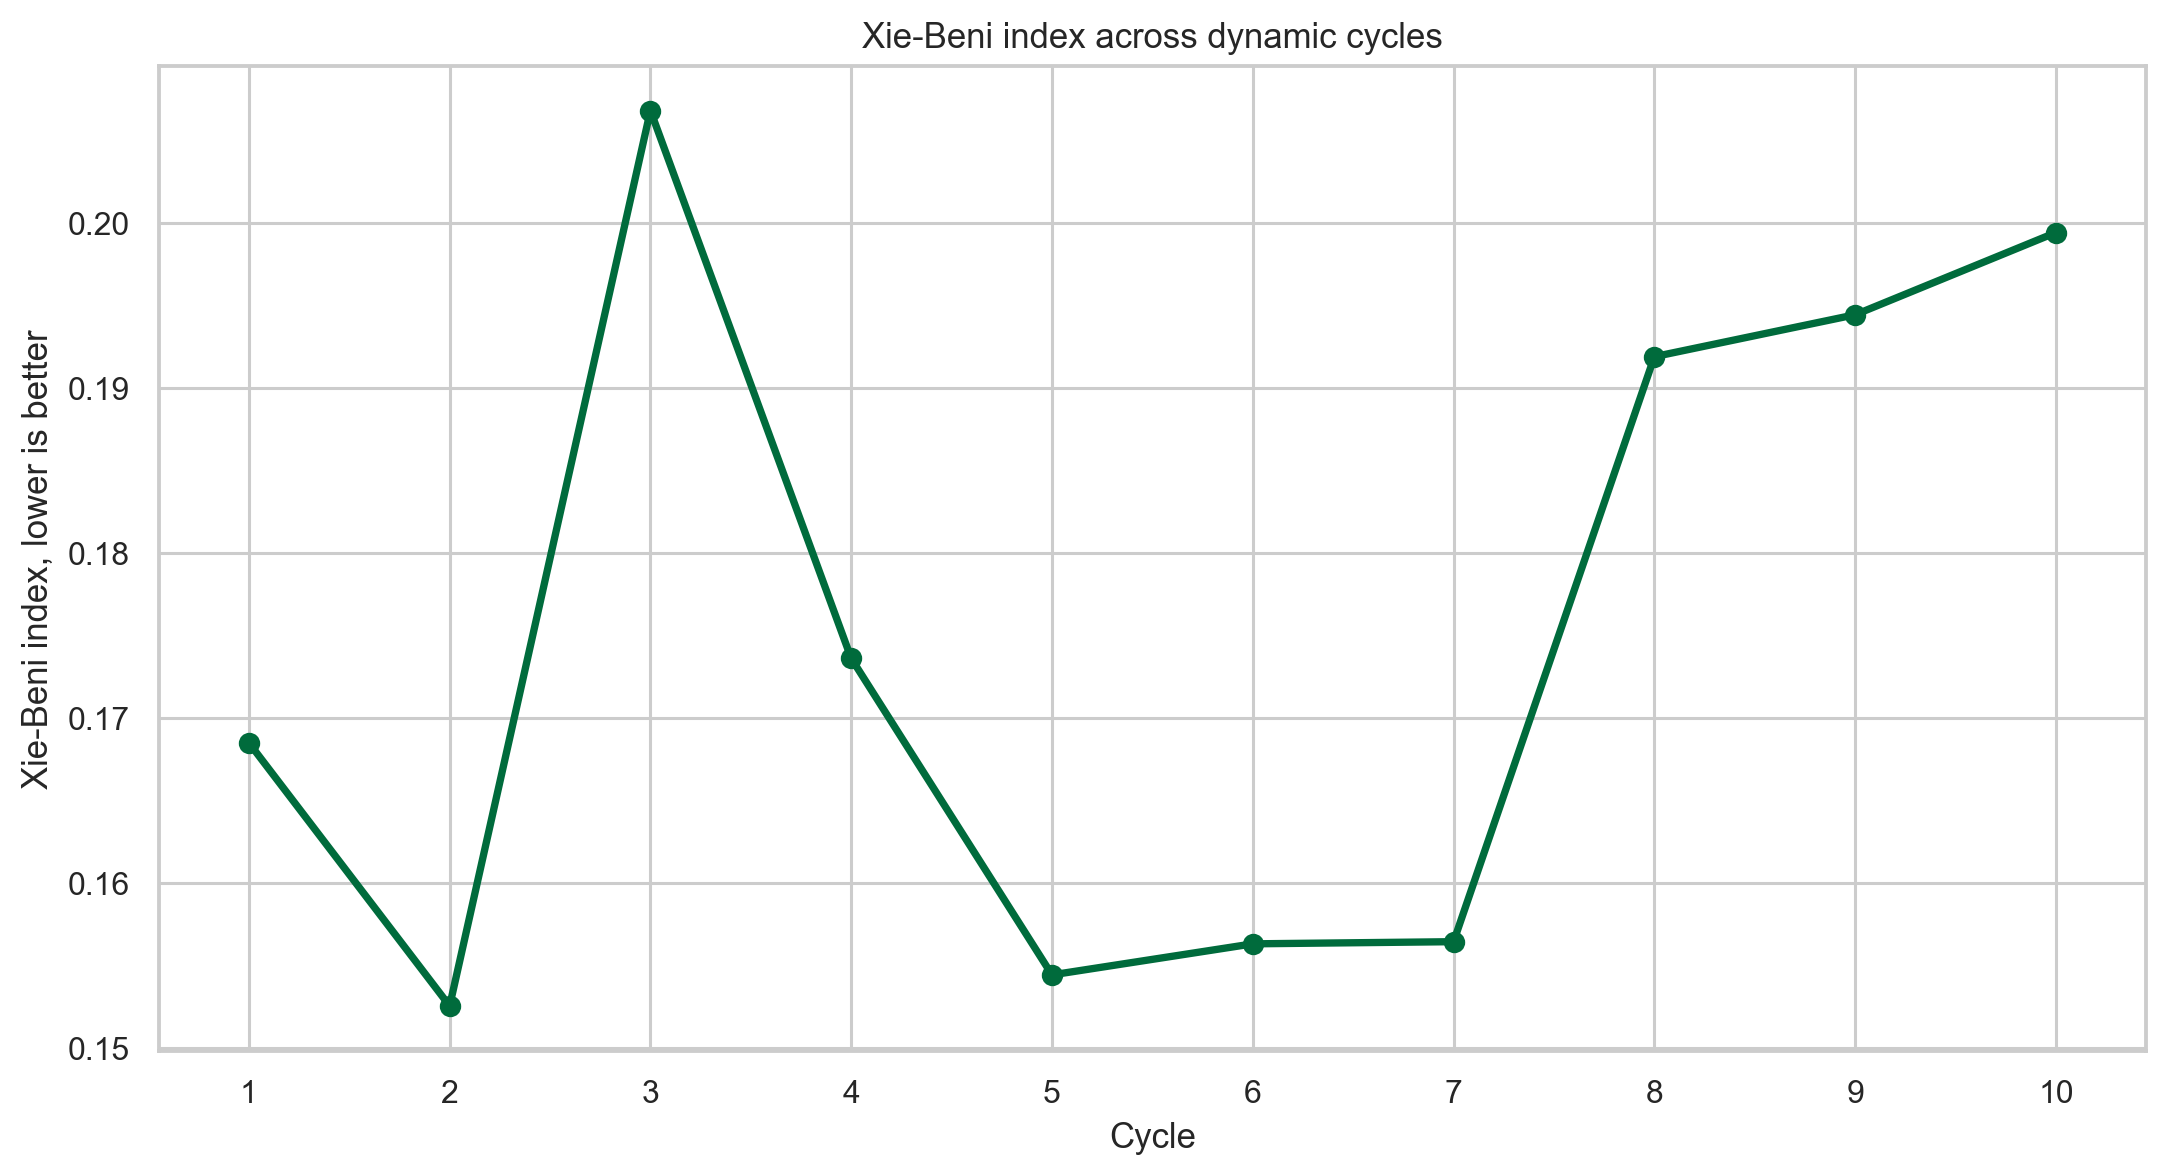

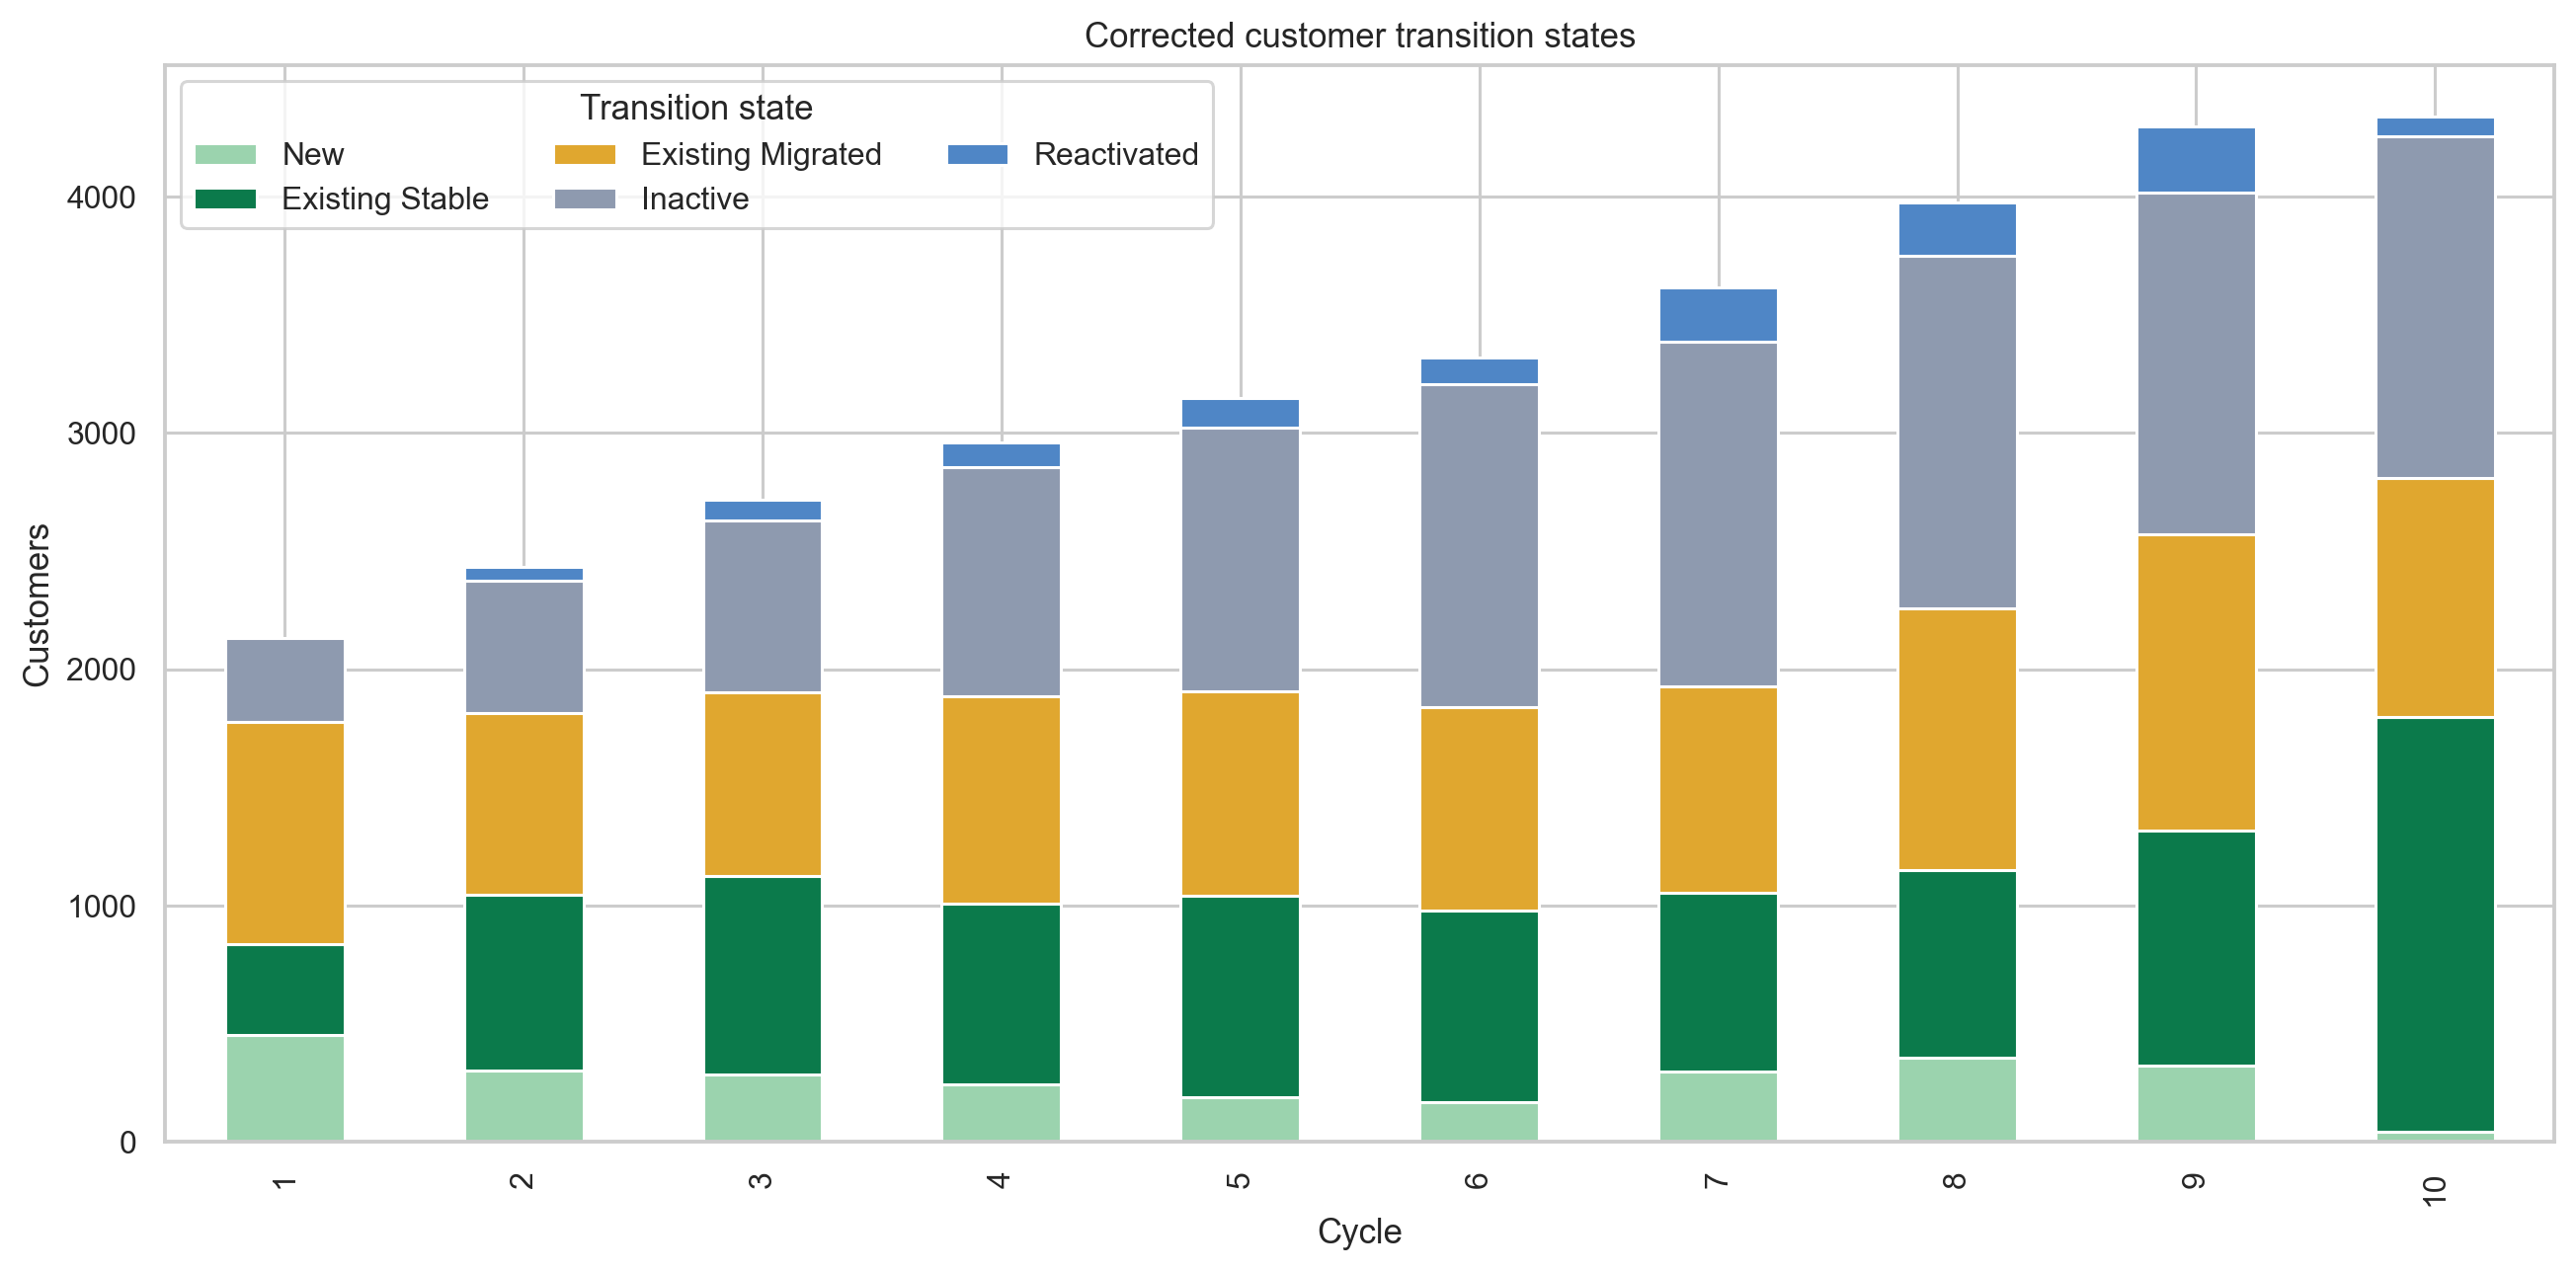

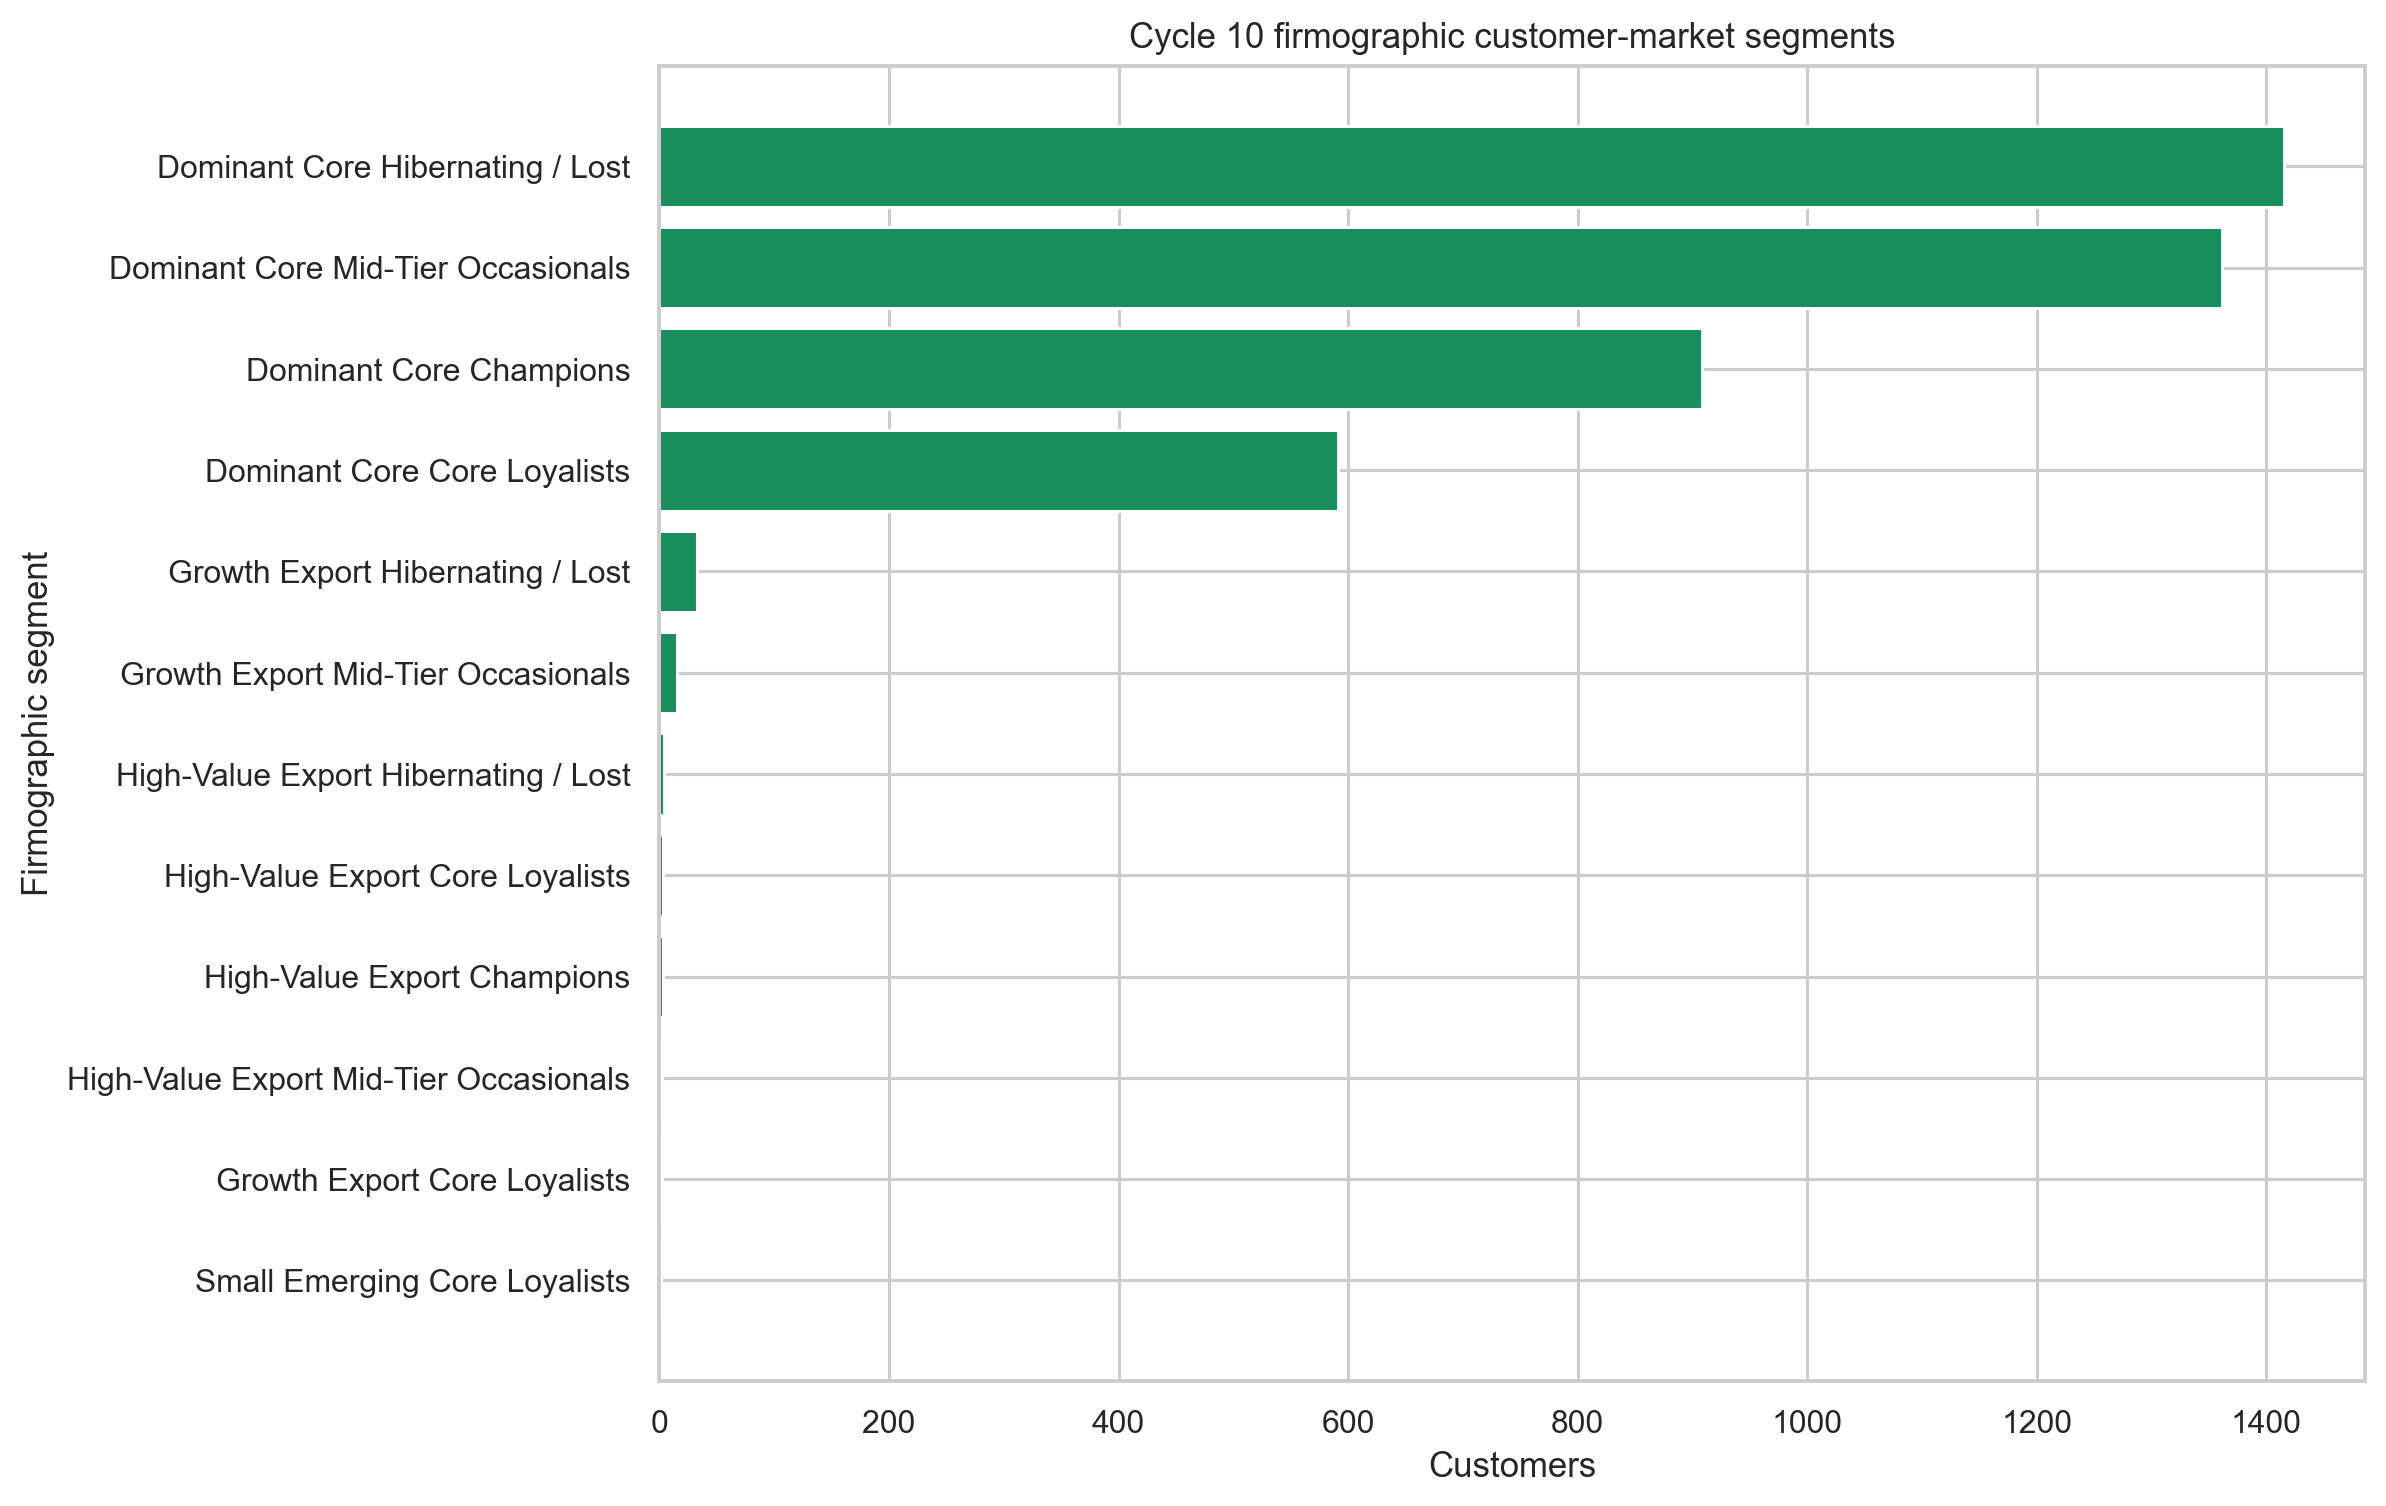

In [7]:
display(Image(filename=str(MODEL_DIRECTORY / 'Research_Figures' / 'Validation' / 'xie_beni_index.png')))
display(Image(filename=str(MODEL_DIRECTORY / 'Research_Figures' / 'Dynamic' / 'customer_transition_states.png')))
display(Image(filename=str(MODEL_DIRECTORY / 'Research_Figures' / 'Firmographic' / 'cycle10_firmographic_segments.png')))